# Dispersion Bias, Part (ii) — heavy-tailed, simplified (ex-2)

Same decomposition study as `ex-1`, stripped to essentials: one `DesignSpec` + one call to
`fl_graphics.nine_panel_decomposition(model, design)` per sweep. Each figure shows the
Eq. (17) split per factor — **sin²** (out-of-subspace + in-subspace stack, measured line) /
**gap** (paired measured − theory) / **out-of-subspace share** — with 95% CI bands and gridlines.
Returns are **heavy-tailed** (student-t).

In [41]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from loguru import logger
logger.remove()  # keep the notebook quiet

from IPython.display import Image, display
from fl_experiment_setup import ModelSpec, DesignSpec
from fl_experiment_runner import run_experiment
from sim_theorem_partii import DispersionBiasExperiment
from fl_graphics import nine_panel_decomposition, top_row_decomposition, six_panel_decomposition  # pure plotters; render to PNG (Agg)

OUT_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR.mkdir(exist_ok=True)

def show(design, name, *, suptitle=None, progress=True):
    """Run the experiment for `design` (tqdm bar over replicates), then plot + display the
    9-panel decomposition. The plotter only consumes the result frame -- it runs nothing.

    Returns ``(fig, df)`` so the caller can re-save the figure (e.g. ``fig.savefig(..., dpi=300)``
    or as PDF/SVG) or reuse the result frame. A PNG is already written to ``OUT_DIR``."""
    df = run_experiment(model, design, DispersionBiasExperiment(), progress=progress)
    path = OUT_DIR / f"ex2_{name}.png"
    fig, _ = nine_panel_decomposition(df, suptitle=suptitle, out_path=str(path))
    display(Image(filename=str(path)))
    return fig, df

# Canonical diagonal-Gram model (factor 1 market-like, c = [1.25, 1, 1]).
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},   # market-like factor (c_1 = 1.25)
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},   # zero-mean
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)

# Heavy tails: student-t factor & idiosyncratic returns, shared by every sweep below.
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    # factor_return_sampler={"distribution": "normal", "loc": 0.0, "scale": 1.0},   # IGNORE --- for comparison with light-tailed case
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
    # idio_return_sampler={"distribution": "normal", "loc": 0.0, "scale": 1.5},

)
N_REPS, SEED = 1000, 20260511   # bump N_REPS to 1000 for publication-quality CIs
print("ready")

ready


In [42]:
if HEAVY_TAIL["factor_return_sampler"]["distribution"] == "student_t":
    factor_return_print = HEAVY_TAIL["factor_return_sampler"]['distribution']+"("+ str(HEAVY_TAIL['factor_return_sampler']['df'])+")"
elif HEAVY_TAIL["factor_return_sampler"]["distribution"] == "normal":
    factor_return_print = HEAVY_TAIL["factor_return_sampler"]["distribution"]+"("+ str(int(HEAVY_TAIL['factor_return_sampler']['loc'])) + ", " + str(int(HEAVY_TAIL['factor_return_sampler']['scale'])) + ")"


idio_return_print = ""

if HEAVY_TAIL["idio_return_sampler"]["distribution"] == "student_t":
    idio_return_print = HEAVY_TAIL["idio_return_sampler"]['distribution']+"("+ str(HEAVY_TAIL['idio_return_sampler']['df'])+")"
elif HEAVY_TAIL["idio_return_sampler"]["distribution"] == "normal":
    idio_return_print = HEAVY_TAIL["idio_return_sampler"]["distribution"]+"("+ str(int(HEAVY_TAIL['idio_return_sampler']['loc'])) + ", " + str(int(HEAVY_TAIL['idio_return_sampler']['scale'])) + ")"


In [43]:
idio_return_print

'student_t(5)'

## Growing $p$ (fixed $n = 63$)

The theorem becomes exact as $p\to\infty$ — watch the **gap** row collapse to zero.

replicate: 100%|██████████| 1000/1000 [01:57<00:00,  8.53rep/s]


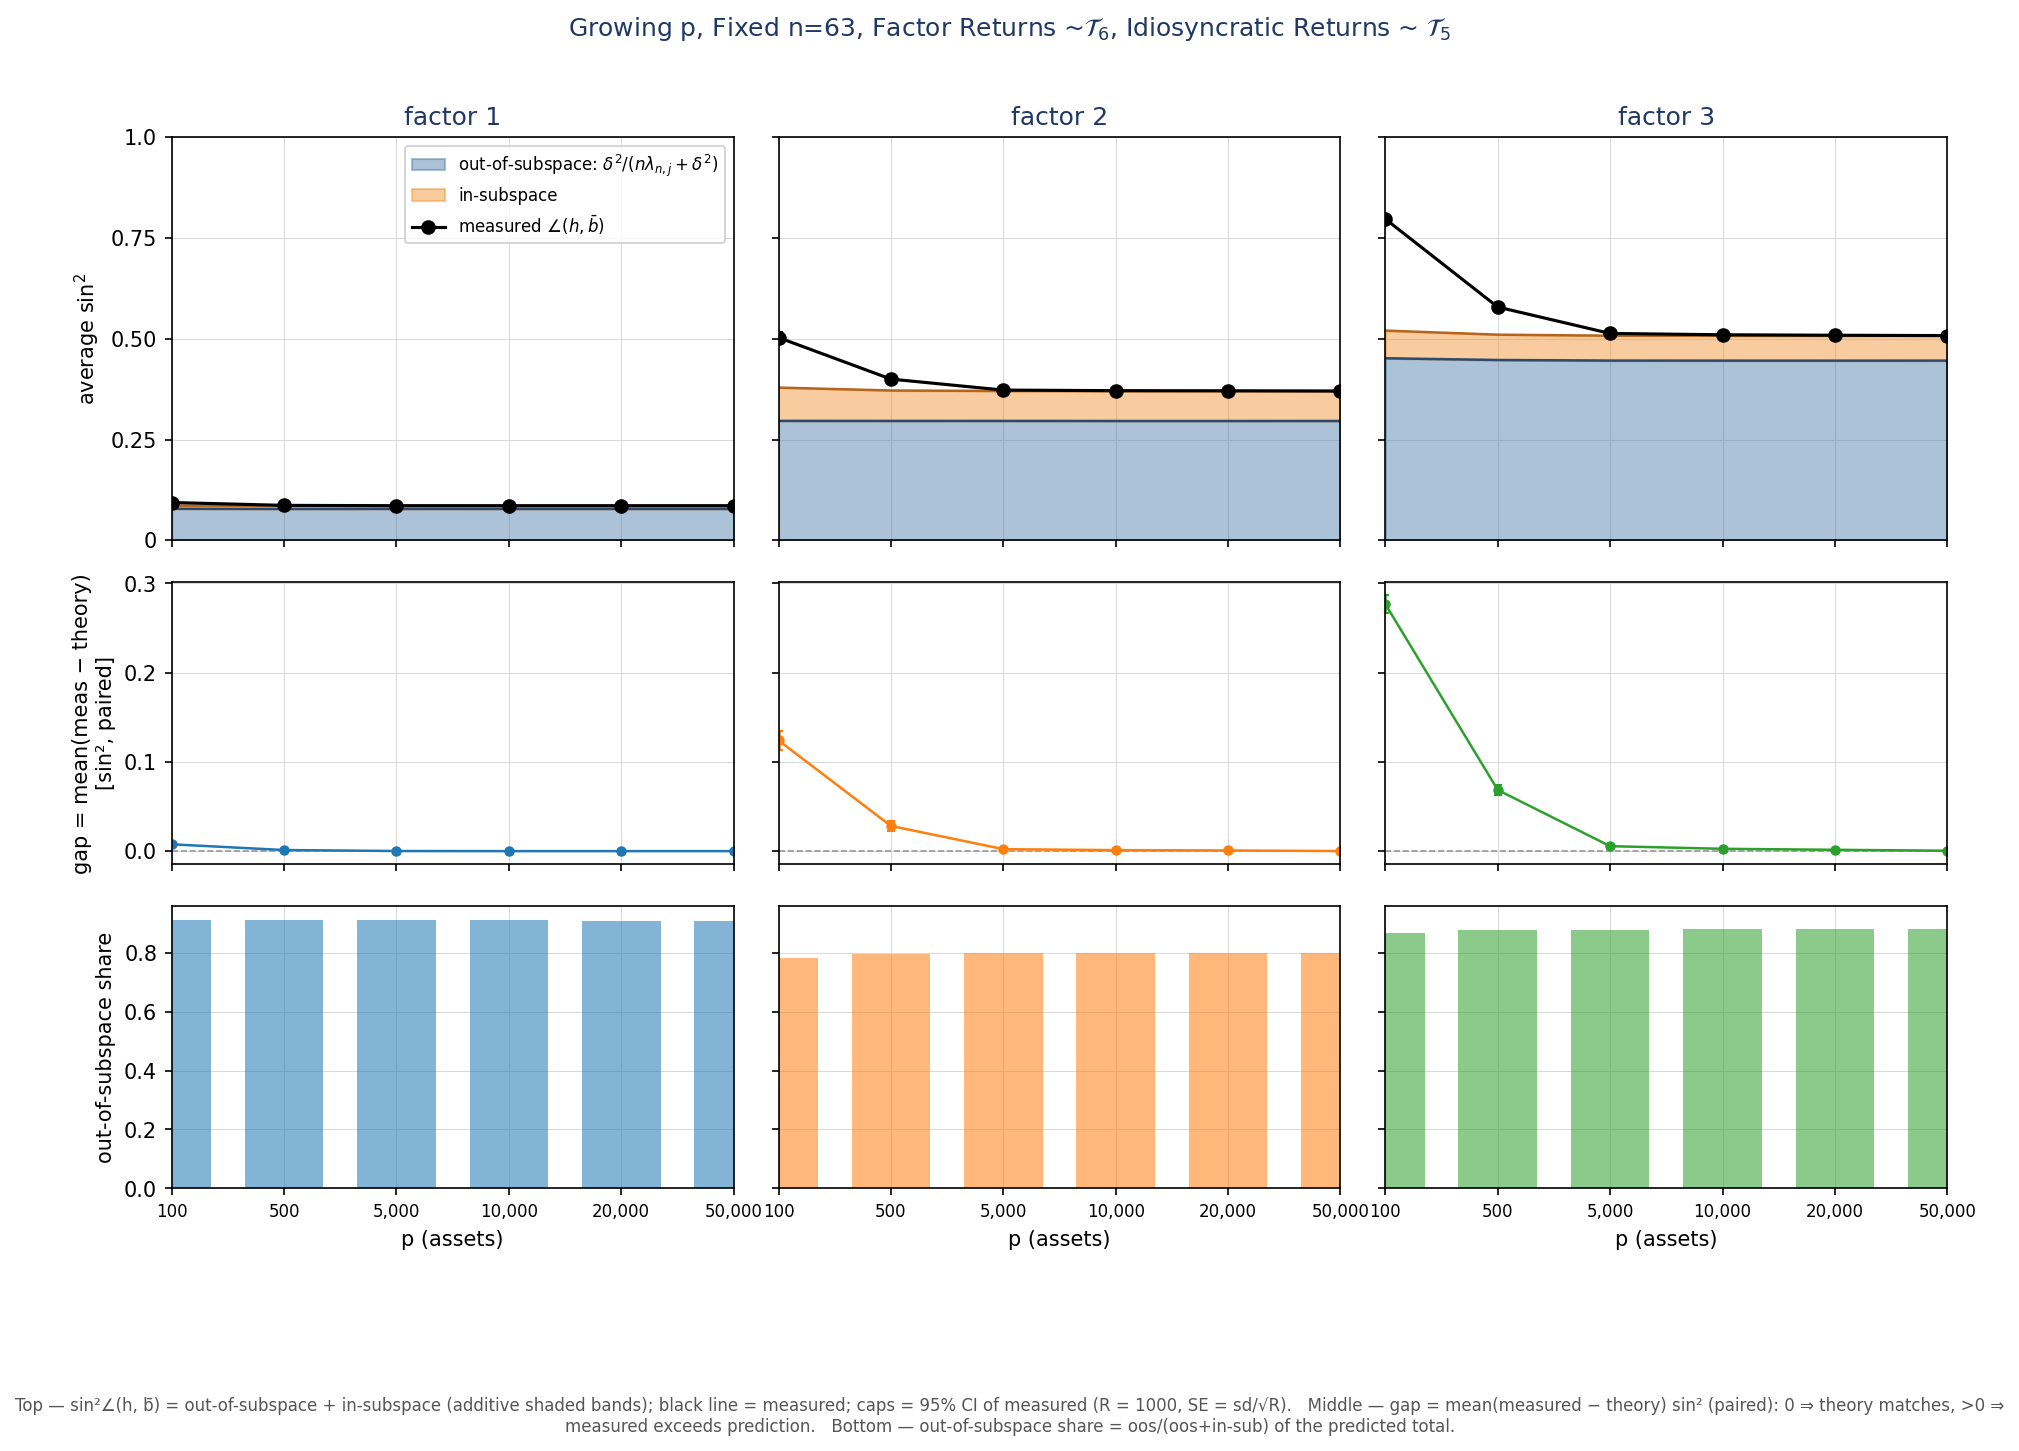

In [44]:
design_p = DesignSpec(
    n_values=[63],
    # p_values=[200, 500, 1000, 2000, 3000, 5000, 10000, 20000],
    p_values = [100, 500, 5000, 10000, 20000, 50000 ],  # for heavy-tailed returns, we need to go bigger on p to see the asymptotic regime
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
return_print = ""
if "normal" in factor_return_print:
    return_print = r"$\mathcal{N}(0,1)$"
elif "student_t" in factor_return_print:
    return_print = rf"$\mathcal{{T}}_{HEAVY_TAIL['factor_return_sampler']['df']}$"

IR_loc = HEAVY_TAIL['idio_return_sampler']['loc']
IR_scale = HEAVY_TAIL['idio_return_sampler']['scale']

idio_print = ""
if "normal" in idio_return_print:
    idio_print = rf"$\mathcal{{N}}({IR_loc:g}, {IR_scale:g})$"
elif "student_t" in idio_return_print:
    idio_print = rf"$\mathcal{{T}}_{HEAVY_TAIL['idio_return_sampler']['df']}$"



fig_p, df_p = show(design_p, "growing_p",suptitle = f"Growing p, Fixed n=63, Factor Returns ~"+ rf"{return_print}, Idiosyncratic Returns ~ {idio_print}", progress=True)

## Fixed $p = 3000$, growing $n$

Both error pieces shrink as $n$ grows ($F^\top F/n \to \Sigma_F$).

In [45]:
# design_n = DesignSpec(
#     n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250],
#     p_values=[3000],
#     n_reps=N_REPS, random_seed=SEED, sampling="nested", **HEAVY_TAIL,
# )
# fig_n, df_n = show(design_n, "growing_n")

## Fixed $p = 3000$, growing $n$ — `nest_time=True`

Nesting the time axis (each $n$ is a prefix of one $n_{\max}$ draw) gives a smoother curve.

replicate: 100%|██████████| 1000/1000 [00:20<00:00, 49.65rep/s]


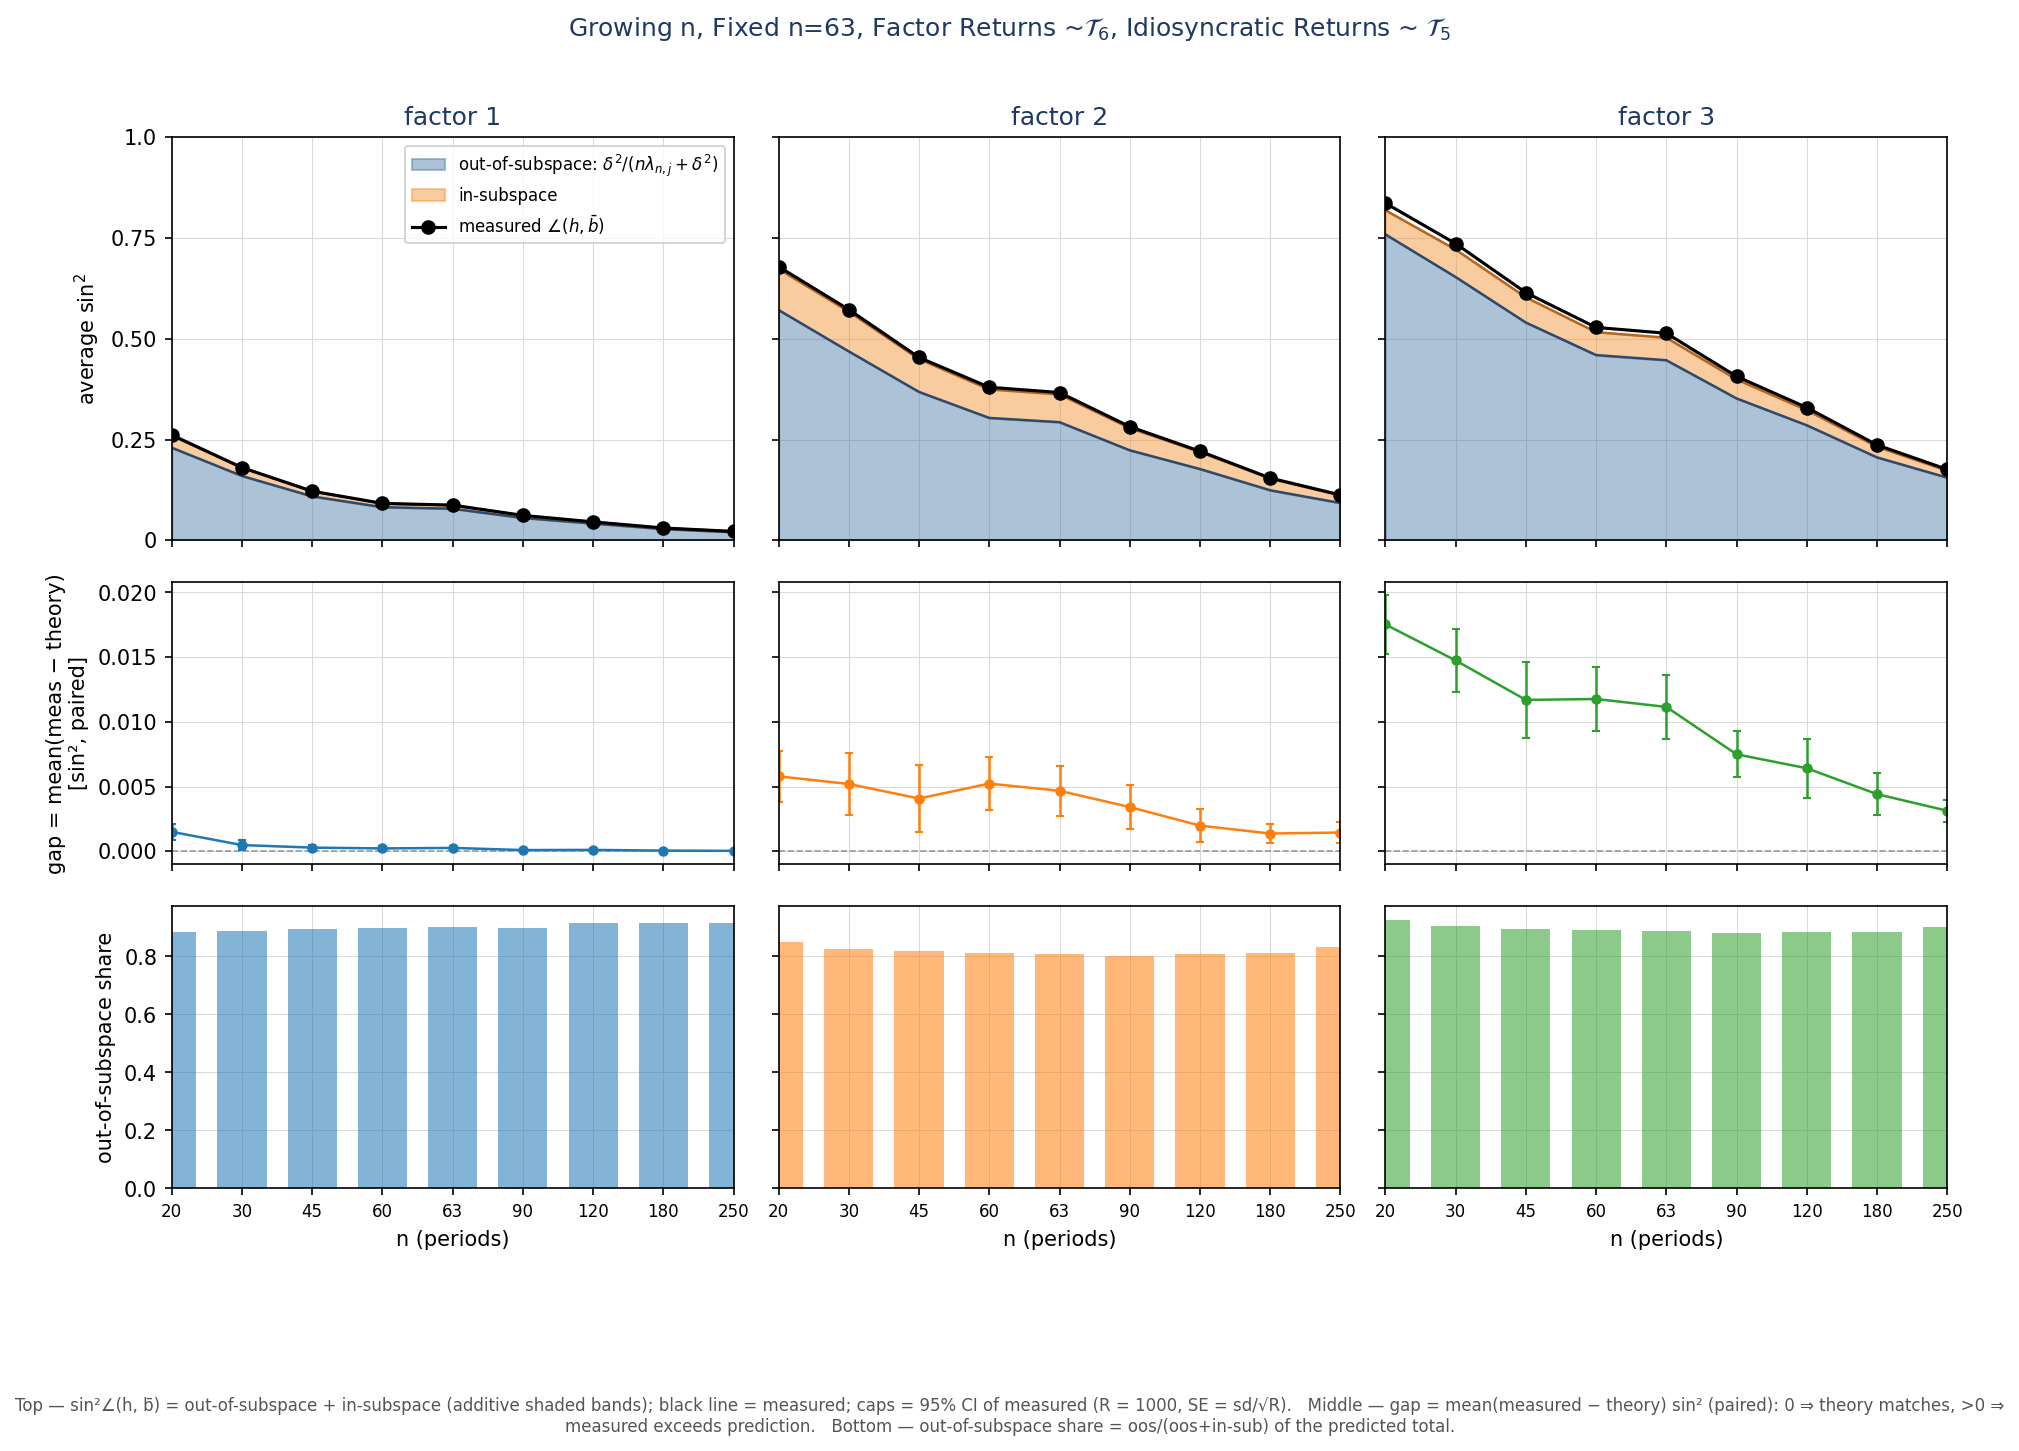

In [46]:
design_nt = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250],
    p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
fig_nt, df_nt = show(design_nt, "nest_time",
     suptitle = f"Growing n, Fixed n=63, Factor Returns ~"+ rf"{return_print}, Idiosyncratic Returns ~ {idio_print}", progress=True)

## Top-row "band" view (standalone)

The 9-panel top row on its own, one panel per factor — rendered by
`fl_graphics.top_row_decomposition`, which shares the exact drawing helper (`_np_top_panel`) with the
full 9-panel figure, so the styling can't drift. Light **blue** = out-of-subspace floor
$\delta^2/(n\lambda_{n,j}+\delta^2)$, **orange** = in-subspace, each with a topline that moves with
the swept axis; **black dots** (measured $\sin^2\angle$, 95% CI caps) ride on top and settle onto the
floor as $p\to\infty$. Pass `topline_ci=True` to overlay translucent 95% CI ribbons on the
floor/total toplines.

/Users/alex/Documents/Finance_Projects/factor_lab/fl_graphics.py:730: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(1, 3, figsize=(13.3, 4.4), sharey=True)


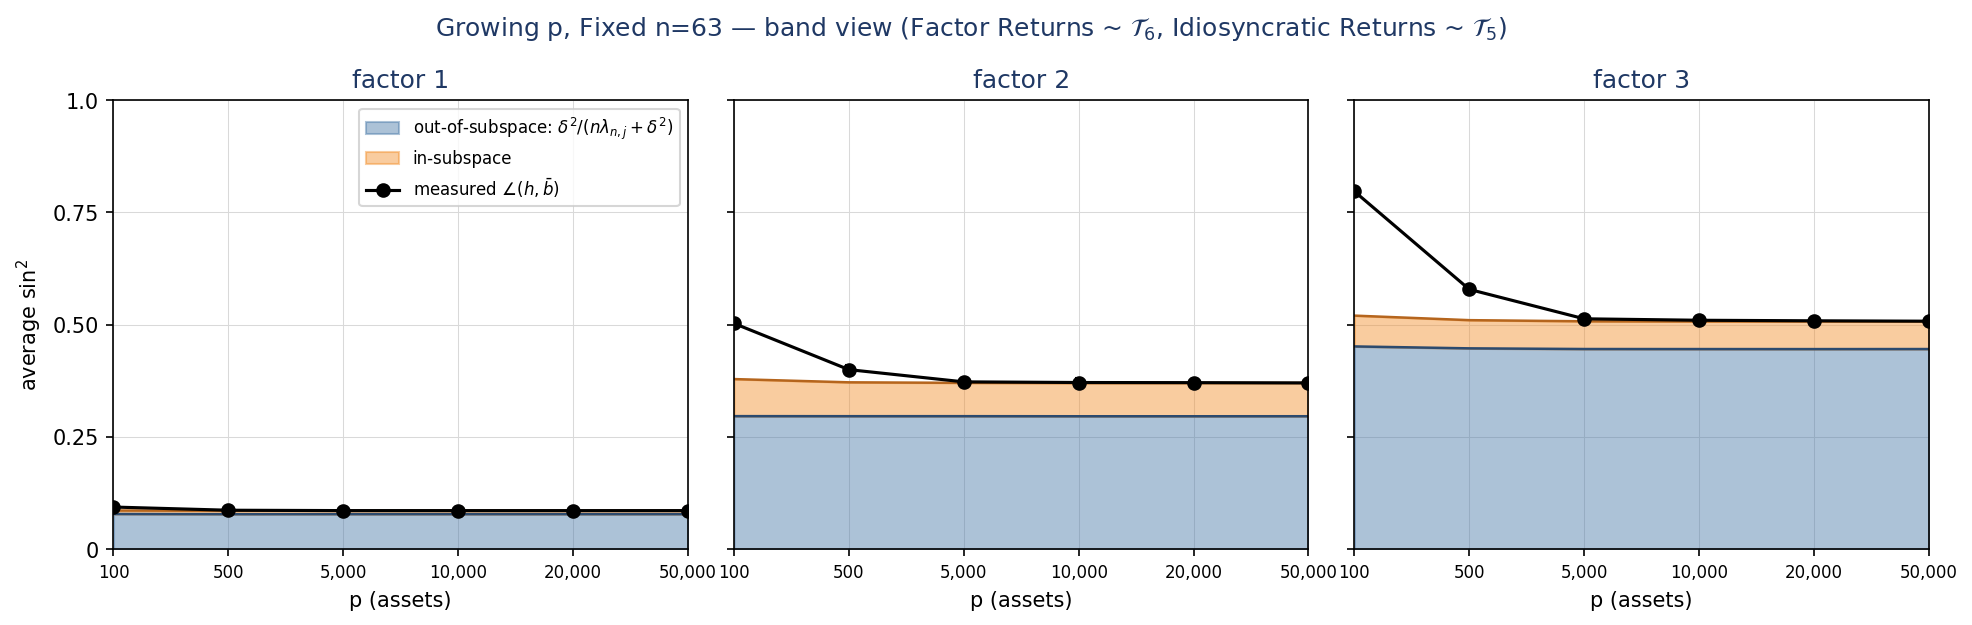

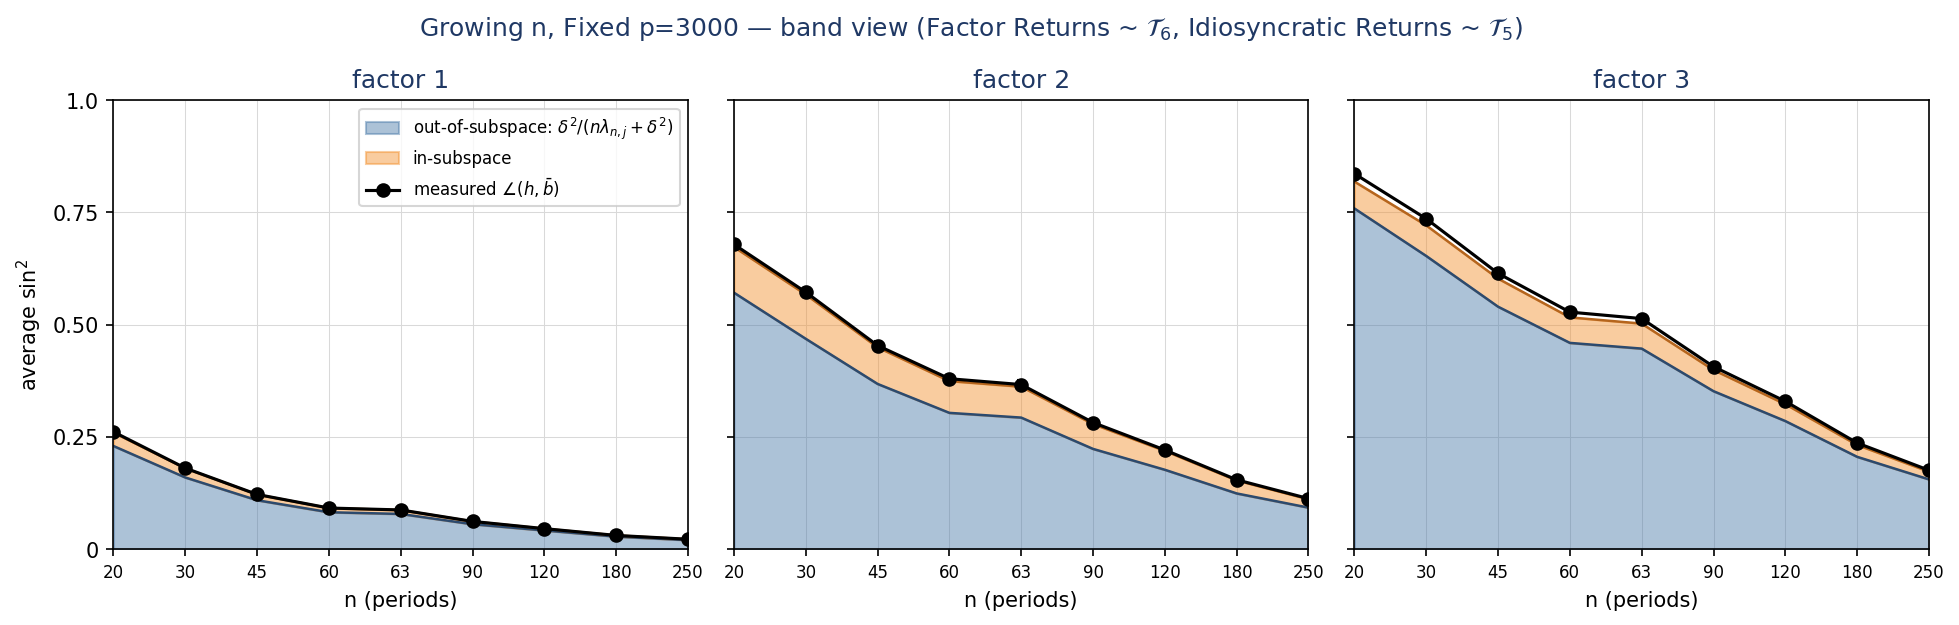

In [47]:
# Standalone top-row "band" view — same shared helper / styling as the 9-panel top row
# (fl_graphics.top_row_decomposition). Pass topline_ci=True to overlay floor/total 95% CI ribbons.
_strip_path_p = OUT_DIR / "ex2_strips_growing_p.png"
_strip_path_n = OUT_DIR / "ex2_strips_growing_n.png"
fig_strip_p, _ = top_row_decomposition(
    df_p, key="p", out_path=str(_strip_path_p),
    suptitle=rf"Growing p, Fixed n=63 — band view (Factor Returns ~ {return_print}, "
             rf"Idiosyncratic Returns ~ {idio_print})",
)
fig_strip_n, _ = top_row_decomposition(
    df_nt, key="n", out_path=str(_strip_path_n),
    suptitle=rf"Growing n, Fixed p=3000 — band view (Factor Returns ~ {return_print}, "
             rf"Idiosyncratic Returns ~ {idio_print})",
)
display(Image(filename=str(_strip_path_p)))
display(Image(filename=str(_strip_path_n)))

## Six-panel view — band top row + per-rep gap boxplots

Same band top row as the 9-panel figure, but the second row swaps the mean±CI **gap** line for a
**boxplot of the per-replicate gap** ($\sin^2_j - \text{rhs}$) at each swept value — showing the
spread across trajectories rather than just the mean. (Third row deliberately omitted for now.)
Rendered by `fl_graphics.six_panel_decomposition`; reuses the shared `_np_top_panel` so the top row
can't drift from the 9-panel one.

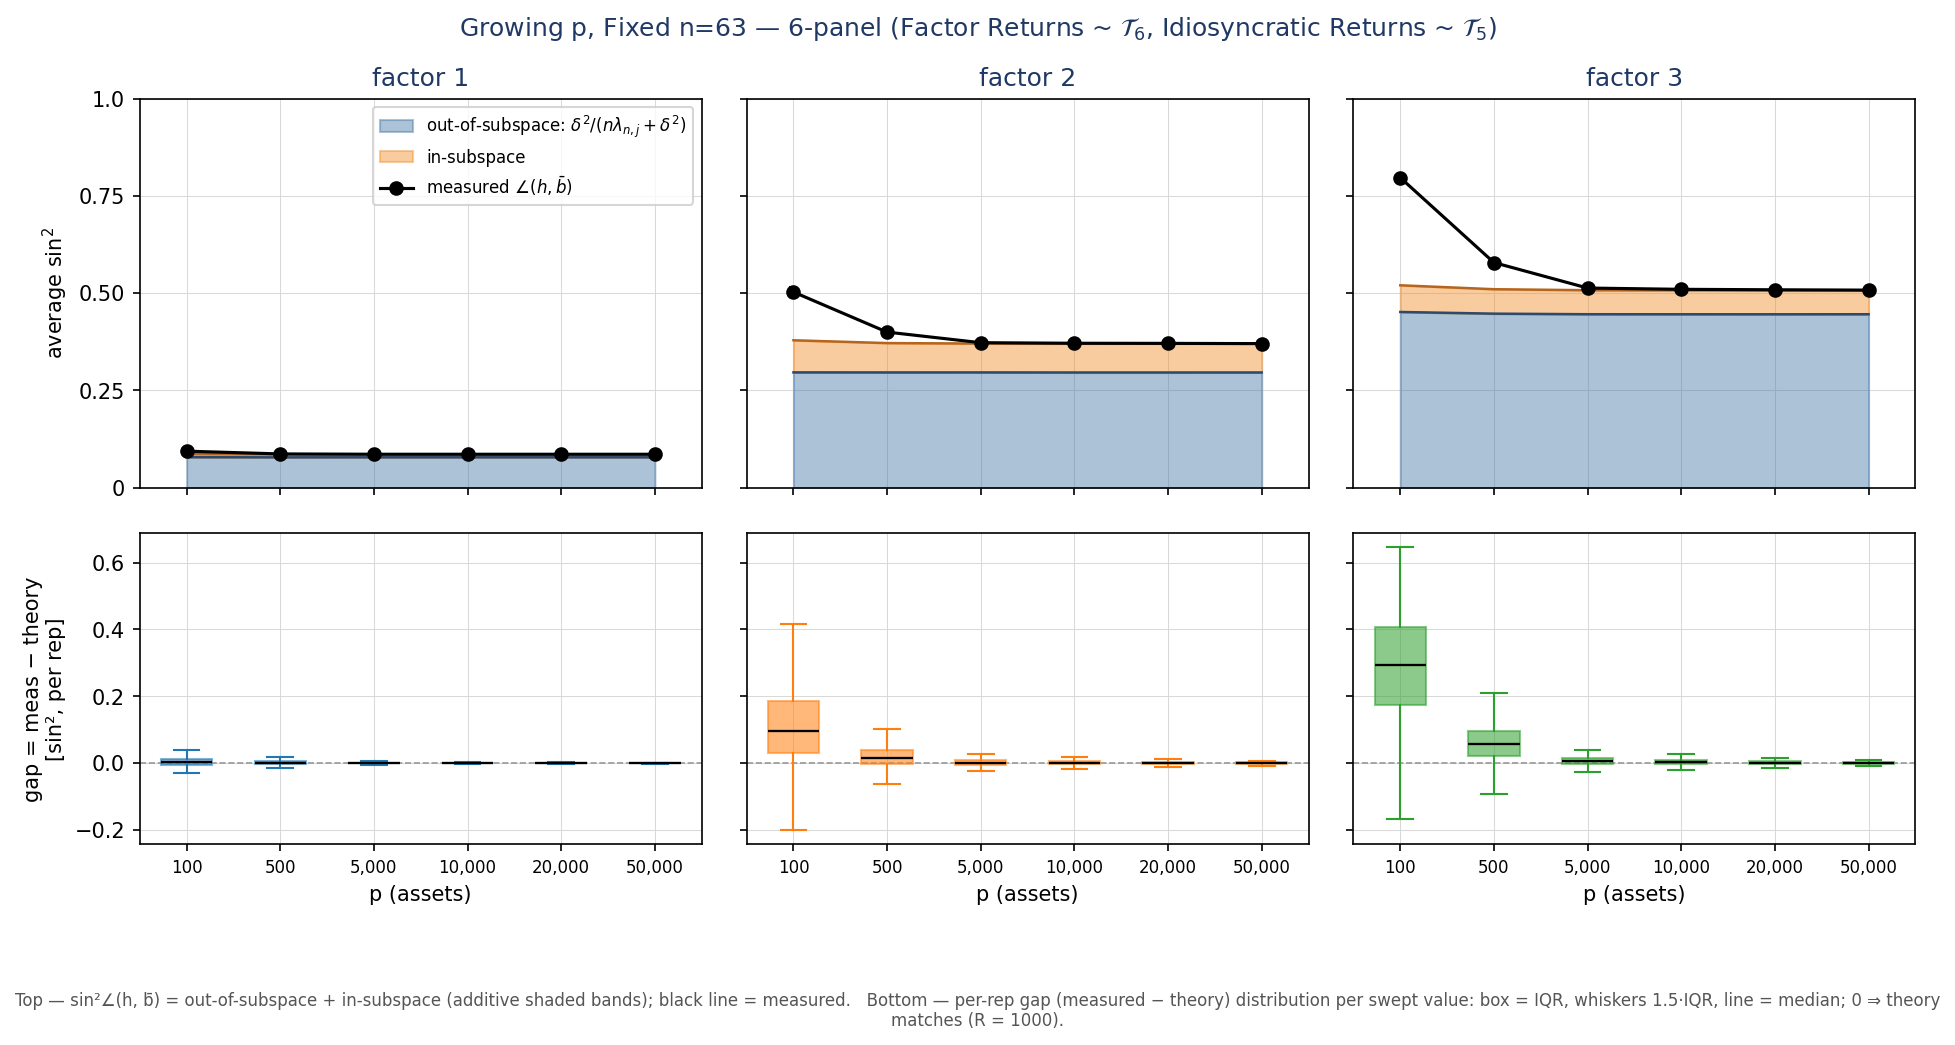

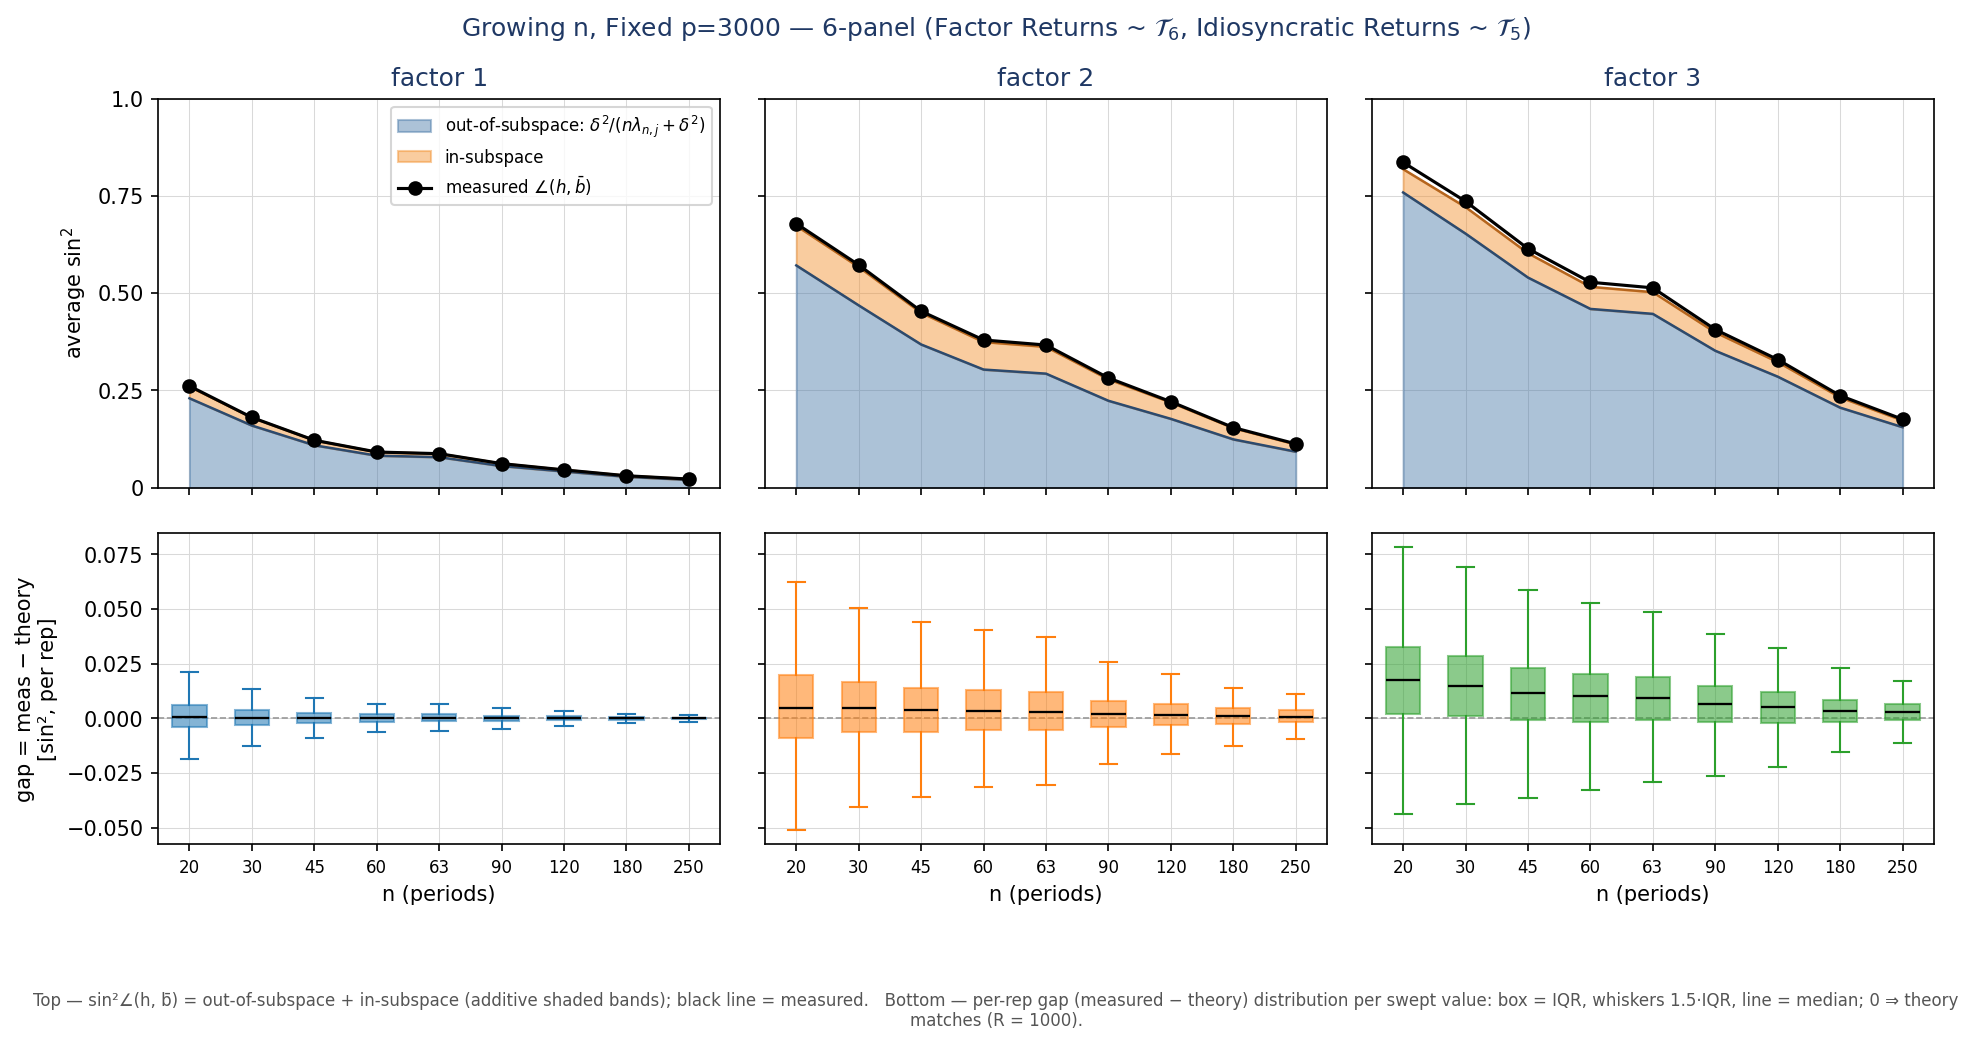

In [48]:
# Six-panel view: band top row + per-rep gap boxplots (2nd row). Reuses the already-computed
# df_p / df_nt — no re-run. Pass topline_ci=True to add floor/total CI ribbons on the top row.
_six_path_p = OUT_DIR / "ex2_six_growing_p.png"
_six_path_n = OUT_DIR / "ex2_six_growing_n.png"
fig_six_p, _ = six_panel_decomposition(
    df_p, key="p", out_path=str(_six_path_p),
    suptitle=rf"Growing p, Fixed n=63 — 6-panel (Factor Returns ~ {return_print}, "
             rf"Idiosyncratic Returns ~ {idio_print})",
)
fig_six_n, _ = six_panel_decomposition(
    df_nt, key="n", out_path=str(_six_path_n),
    suptitle=rf"Growing n, Fixed p=3000 — 6-panel (Factor Returns ~ {return_print}, "
             rf"Idiosyncratic Returns ~ {idio_print})",
)
display(Image(filename=str(_six_path_p)))
display(Image(filename=str(_six_path_n)))

In [49]:
#### SAVE FIGURES


# fig_p.savefig(OUT_DIR / "v2_heavy_tail_growing_p.pdf", dpi=300, bbox_inches="tight")
# fig_nt.savefig(OUT_DIR / "v2_heavy_tail_growing_n.pdf", dpi=300, bbox_inches="tight")
# fig_strip_p.savefig(OUT_DIR / "v2_heavy_tail_growing_p_top_row.pdf", dpi=300, bbox_inches="tight")
# fig_strip_n.savefig(OUT_DIR / "v2_heavy_tail_growing_n_top_row.pdf", dpi=300, bbox_inches="tight")
# fig_six_p.savefig(OUT_DIR / "v3_heavy_tail_growing_p_six_panel.pdf", dpi=300, bbox_inches="tight")
# fig_six_n.savefig(OUT_DIR / "v3_heavy_tail_growing_n_six_panel.pdf", dpi=300, bbox_inches="tight")

## Growing $p$ — specific numbers

Measured angles $\angle(h_j,\bar b_j)$ at $p = 500$ (translating $\sin^2\angle$ to degrees) and
the out-of-subspace share of the asymptotic (largest-$p$) error.

In [50]:
import numpy as np

# Per-(p, factor) means from the growing-p sweep (df_p).
_g = (df_p.groupby(["p", "j"])
          .agg(sin2=("sin2_j", "mean"), oos=("floor", "mean"), theory=("rhs", "mean"))
          .reset_index())

# 1) Measured angles ∠(h_j, b̄_j) at p = P0  (sin²∠ → degrees: ∠ = arcsin√sin²).
P0 = 500
ang = {int(j): np.degrees(np.arcsin(np.sqrt(np.clip(
          _g.loc[(_g.p == P0) & (_g.j == j), "sin2"].iloc[0], 0.0, 1.0))))
       for j in (1, 2, 3)}
print(f"Translating from units of sine-squared to angles, ∠(h_j, b̄_j) for p = {P0} are "
      + ", ".join(f"{ang[j]:.1f}°" for j in (1, 2, 3)) + "  (factors 1, 2, 3).")

# 2) Out-of-subspace share (oos / predicted total) of the asymptotic (largest-p) error,
#    averaged over the three factors.
P_inf = int(_g["p"].max())
_a = _g[_g.p == P_inf].sort_values("j")
share_j = _a["oos"].to_numpy() / _a["theory"].to_numpy()
print(f"The average out-of-subspace component of the asymptotic error (p = {P_inf:,}) "
      f"accounts for {100 * share_j.mean():.0f}%.")
print("  out-of-subspace share per factor:", ", ".join(f"{100*s:.0f}%" for s in share_j))

Translating from units of sine-squared to angles, ∠(h_j, b̄_j) for p = 500 are 17.1°, 39.2°, 49.5°  (factors 1, 2, 3).
The average out-of-subspace component of the asymptotic error (p = 50,000) accounts for 86%.
  out-of-subspace share per factor: 91%, 80%, 88%


## Error tables — gap (measured − theory) quartiles

Table form of the 6-panel **bottom row**: the per-replicate gap $\sin^2_j-\text{rhs}$
summarized by mean, median, Q1 (25th pct) and Q3 (75th pct) for every swept value and factor,
for growing $p$ and growing $n$. (Q1/Q3 are the box edges; whisker line = median.)

In [51]:
def error_quartile_table(df, key):
    """Table form of the 6-panel bottom row: per-rep gap (measured − theory = sin2_j − rhs)
    summarized per (swept value, factor) by mean / median / Q1 (25%) / Q3 (75%)."""
    g = df.assign(gap=df["sin2_j"] - df["rhs"])
    return (g.groupby([key, "j"])["gap"]
             .agg(mean="mean", median="median",
                  q1=lambda s: s.quantile(0.25),
                  q3=lambda s: s.quantile(0.75),
                  reps="size")
             .reset_index()
             .rename(columns={"j": "factor"})
             .round({"mean": 5, "median": 5, "q1": 5, "q3": 5}))

tbl_gap_p = error_quartile_table(df_p, "p")     # growing p, fixed n=63
tbl_gap_n = error_quartile_table(df_nt, "n")    # growing n, fixed p=3000

print("Growing p (fixed n=63) — gap = measured − theory  [sin², per rep]")
display(tbl_gap_p)
print("Growing n (fixed p=3000) — gap = measured − theory  [sin², per rep]")
display(tbl_gap_n)

Growing p (fixed n=63) — gap = measured − theory  [sin², per rep]


,p,factor,mean,median,q1,q3,reps
0,100,1,0.00763,0.00351,-0.00475,0.01304,1000
1,100,2,0.12404,0.09618,0.02931,0.18526,1000
2,100,3,0.27672,0.29251,0.17418,0.40801,1000
3,500,1,0.00124,0.00063,-0.00304,0.00519,1000
4,500,2,0.02826,0.01585,-0.00284,0.03992,1000
5,500,3,0.06853,0.05567,0.02139,0.09743,1000
6,5000,1,0.00012,0.00005,-0.00119,0.00143,1000
7,5000,2,0.00223,0.00161,-0.00455,0.00824,1000
8,5000,3,0.00556,0.00489,-0.00231,0.01430,1000
9,10000,1,0.00000,-0.00003,-0.00084,0.00089,1000


Growing n (fixed p=3000) — gap = measured − theory  [sin², per rep]


,n,factor,mean,median,q1,q3,reps
0,20,1,0.00150,0.00076,-0.00400,0.00613,1000
1,20,2,0.00579,0.00459,-0.00892,0.02000,1000
2,20,3,0.01753,0.01754,0.00214,0.03273,1000
3,30,1,0.00048,0.00034,-0.00278,0.00388,1000
4,30,2,0.00520,0.00464,-0.00629,0.01679,1000
5,30,3,0.01474,0.01506,0.00130,0.02861,1000
6,45,1,0.00028,0.00022,-0.00202,0.00263,1000
7,45,2,0.00408,0.00382,-0.00602,0.01396,1000
8,45,3,0.01170,0.01156,-0.00065,0.02322,1000
9,60,1,0.00022,0.00020,-0.00147,0.00193,1000


In [52]:
df_nt_percent = df_nt.loc

In [53]:
g = df_nt.groupby(["rhs", "j", "n"]).agg(floor=("floor", "mean"), meas=("rhs", "mean"))
g["oos_pct"] = 100 * g["floor"] / g["meas"]      # floor / realized error


In [54]:
g = (df_nt.groupby(["j", "n"])
       .agg(floor=("floor", "mean"), rhs=("rhs", "mean")))
g["oos_pct"] = 100 * g["floor"] / g["rhs"]

g["oos_pct"]                  # Series, MultiIndex (j, n) — organized by factor then n
g["oos_pct"].unstack("n")     # 2-D table: rows = factor j, cols = n


n,20,30,45,60,63,90,120,180,250
j,,,,,,,,,
1,88.424811,88.688222,89.588369,89.970034,90.041571,89.980492,91.405454,91.664021,91.673359
2,84.882596,82.603898,81.873376,81.077112,80.963957,80.142965,80.742865,81.036229,83.189847
3,92.680711,90.549551,89.614530,88.989905,88.905299,88.182481,88.370874,88.591969,90.030188


## Out-of-subspace share tables (% of predicted error)

Out-of-subspace share $=\text{floor}/\text{rhs}$ (a fraction of the *predicted* error, not the
noisy realized $\sin^2$) as a **factor × swept-value** table, 2 d.p., for growing $p$ and growing
$n$. Each cell is a ratio of per-rep means. LaTeX export carries the % sign.

In [ ]:
def oos_share_table(df, key):
    """Out-of-subspace share (% of predicted error = floor/rhs), as a factor × {key} table,
    rounded to 2 d.p. Each cell is the ratio of per-(factor, key) means."""
    g = df.groupby(["j", key]).agg(floor=("floor", "mean"), rhs=("rhs", "mean"))
    g["oos_pct"] = 100 * g["floor"] / g["rhs"]
    tbl = g["oos_pct"].unstack(key).round(2)
    tbl.index.name = "factor"
    tbl.columns.name = key
    return tbl

def oos_latex(tbl, key, fixed):
    """LaTeX for an oos_share_table: 2 d.p. with a % on each value (needs \\usepackage{booktabs})."""
    return tbl.to_latex(
        float_format=lambda v: f"{v:.2f}\\%",   # % stamped on each value
        escape=False,                            # keep the backslash before %
        caption=rf"Out-of-subspace share (\% of predicted error), {fixed}, growing ${key}$.",
        label=f"tab:oos_growing_{key}",
        column_format="l" + "r" * tbl.shape[1],
    )

oos_p = oos_share_table(df_p, "p")     # growing p, fixed n=63
oos_n = oos_share_table(df_nt, "n")    # growing n, fixed p=3000

print("Out-of-subspace share (% of predicted error) — growing p (fixed n=63)")
display(oos_p)
print("Out-of-subspace share (% of predicted error) — growing n (fixed p=3000)")
display(oos_n)

print(oos_latex(oos_p, "p", r"fixed $n=63$"))


Out-of-subspace share (% of predicted error) — growing p (fixed n=63)


p,100,500,5000,10000,20000,50000
factor,,,,,,
1,90.92,91.18,90.98,90.91,90.90,90.90
2,78.20,79.69,79.96,79.98,79.97,79.97
3,86.81,87.68,87.83,87.87,87.87,87.86


Out-of-subspace share (% of predicted error) — growing n (fixed p=3000)


n,20,30,45,60,63,90,120,180,250
factor,,,,,,,,,
1,88.42,88.69,89.59,89.97,90.04,89.98,91.41,91.66,91.67
2,84.88,82.60,81.87,81.08,80.96,80.14,80.74,81.04,83.19
3,92.68,90.55,89.61,88.99,88.91,88.18,88.37,88.59,90.03


\begin{table}
\caption{Out-of-subspace share (\% of predicted error), fixed $n=63$, growing $p$.}
\label{tab:oos_growing_p}
\begin{tabular}{lrrrrrr}
\toprule
p & 100 & 500 & 5000 & 10000 & 20000 & 50000 \\
factor &  &  &  &  &  &  \\
\midrule
1 & 90.92\% & 91.18\% & 90.98\% & 90.91\% & 90.90\% & 90.90\% \\
2 & 78.20\% & 79.69\% & 79.96\% & 79.98\% & 79.97\% & 79.97\% \\
3 & 86.81\% & 87.68\% & 87.83\% & 87.87\% & 87.87\% & 87.86\% \\
\bottomrule
\end{tabular}
\end{table}

\begin{table}
\caption{Out-of-subspace share (\% of predicted error), fixed $p=3000$, growing $n$.}
\label{tab:oos_growing_n}
\begin{tabular}{lrrrrrrrrr}
\toprule
n & 20 & 30 & 45 & 60 & 63 & 90 & 120 & 180 & 250 \\
factor &  &  &  &  &  &  &  &  &  \\
\midrule
1 & 88.42\% & 88.69\% & 89.59\% & 89.97\% & 90.04\% & 89.98\% & 91.41\% & 91.66\% & 91.67\% \\
2 & 84.88\% & 82.60\% & 81.87\% & 81.08\% & 80.96\% & 80.14\% & 80.74\% & 81.04\% & 83.19\% \\
3 & 92.68\% & 90.55\% & 89.61\% & 88.99\% & 88.91\% & 88.18\% & 88.37\%

In [56]:
print(oos_latex(oos_n, "n", r"fixed $p=3000$"))

\begin{table}
\caption{Out-of-subspace share (\% of predicted error), fixed $p=3000$, growing $n$.}
\label{tab:oos_growing_n}
\begin{tabular}{lrrrrrrrrr}
\toprule
n & 20 & 30 & 45 & 60 & 63 & 90 & 120 & 180 & 250 \\
factor &  &  &  &  &  &  &  &  &  \\
\midrule
1 & 88.42\% & 88.69\% & 89.59\% & 89.97\% & 90.04\% & 89.98\% & 91.41\% & 91.66\% & 91.67\% \\
2 & 84.88\% & 82.60\% & 81.87\% & 81.08\% & 80.96\% & 80.14\% & 80.74\% & 81.04\% & 83.19\% \\
3 & 92.68\% & 90.55\% & 89.61\% & 88.99\% & 88.91\% & 88.18\% & 88.37\% & 88.59\% & 90.03\% \\
\bottomrule
\end{tabular}
\end{table}



In [61]:
df_nt

,n,p,j,sin2_j,rhs,gap,floor,rotation,rho,rep
0,20,3000,1,0.239122,0.243038,-0.003916,0.199790,0.054046,0.032042,0
1,20,3000,2,0.430576,0.442665,-0.012089,0.408327,0.058035,0.011592,0
2,20,3000,3,0.675624,0.656514,0.019111,0.654731,0.005163,0.004219,0
3,30,3000,1,0.150003,0.151943,-0.001940,0.146877,0.005938,0.030978,0
4,30,3000,2,0.329321,0.344685,-0.015363,0.342469,0.003369,0.010240,0
...,...,...,...,...,...,...,...,...,...,...
26995,180,3000,2,0.162441,0.165837,-0.003396,0.161231,0.005492,0.004624,999
26996,180,3000,3,0.255139,0.245169,0.009970,0.244581,0.000779,0.002745,999
26997,250,3000,1,0.023812,0.023282,0.000530,0.020634,0.002704,0.030377,999
26998,250,3000,2,0.116699,0.113681,0.003018,0.111112,0.002890,0.005120,999


# Average Measured Angles
## lefthand side

In [72]:
import numpy as np

# 1) per-rep: sin² → angle (degrees).  clip guards sin² slightly >1 from noise (→ NaN otherwise)
ang = df_nt.assign(angle=np.degrees(np.arcsin(np.sqrt(df_nt["sin2_j"].clip(0, 1)))))
ang_rhs = df_nt.assign(angle=np.degrees(np.arcsin(np.sqrt(df_nt["rhs"].clip(0, 1)))))

# 2) aggregate: mean angle per (factor, key)
per_group = ang.groupby(["j", "n"])["angle"].mean()      # Series, MultiIndex (j, n)
# per_group_rhs = ang_rhs.groupby(["j", "n"])["angle"].mean()  # Series, MultiIndex (j, n)
per_group.unstack("n").round(2)
# # 3) mean across the (j, n) groups
# per_group.mean()


n,20,30,45,60,63,90,120,180,250
j,,,,,,,,,
1,30.42,24.84,20.21,17.43,17.01,14.25,12.26,10.01,8.49
2,56.68,49.94,42.68,38.12,37.32,31.90,27.79,22.85,19.37
3,67.30,59.84,52.11,46.92,46.07,39.68,35.01,29.01,24.69


## Righthand-Side Angles

In [68]:
per_group_rhs.unstack("n").round(2)


n,20,30,45,60,63,90,120,180,250
j,,,,,,,,,
1,30.33,24.81,20.19,17.41,16.99,14.24,12.25,10.00,8.48
2,56.28,49.61,42.45,37.79,37.03,31.68,27.63,22.76,19.24
3,65.75,58.83,51.40,46.19,45.38,39.24,34.59,28.73,24.45
